# Personal light exposure: Metric preparation

Individual, behavioural, and environmental determinants of personal light exposure in daily life: a multi-country wearable and experience-sampling study

## Preface

This script works off [the data preprocessing](data_preparation.qmd), to produce one dataframe containing all metrics in numeric form, ready for analysis.

### How metrics must be interpreted

- Timing and duration-based metrics are converted to decimal-hours.
- In the case of timing they mean decimal-hours from midnight.
- The `darkest_10h` are centered on midnight, i.e., values before midnight are negative.
- `mean` value metrics used a geometric mean (with `log_zero_inflated()`).

For a single, unnested dataframe of metrics execute:

    metrics_glasses |> unnest(data)

## Setup

In [ ]:
library(tidyverse)


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Loading required package: nlme

Attaching package: 'nlme'

The following object is masked from 'package:dplyr':

    collapse

This is mgcv 1.9-4. For overview type '?mgcv'.

Loading required package: Matrix

Attaching package: 'Matrix'

The following objects are masked from 'package:tidyr':

    expand, pack, unpack


Attaching package: 'lme4'

The following object is masked from 'package:nlme':

    lmList


Attaching package: 'cowplot'

The following object is masked from 'package:lubridate':

    stamp

In [ ]:
load("data/metrics_separate_glasses.RData")
load("data/metrics_separate_chest.RData")
load("data/preprocessed_glasses_2.RData")
load("data/preprocessed_chest_2.RData")
demographics <- load_data("demographics") |> flatten_data()


## Preparation

### Context

In [ ]:
photoperiod_daily <- 
light_glasses_processed2 |> 
  group_by(site, Id, Date) |> 
  summarize(photoperiod = mean(photoperiod, na.rm = TRUE) |> as.numeric(),
            .groups = "drop_last")

photoperiod_participant <- 
light_glasses_processed2 |> 
  group_by(site, Id) |> 
  summarize(photoperiod = mean(photoperiod, na.rm = TRUE) |> as.numeric(),
            .groups = "drop_last")

photoperiod_daily_chest <- 
light_chest_processed2 |> 
  group_by(site, Id, Date) |> 
  summarize(photoperiod = mean(photoperiod, na.rm = TRUE) |> as.numeric(),
            .groups = "drop_last")

photoperiod_participant_chest <- 
light_chest_processed2 |> 
  group_by(site, Id) |> 
  summarize(photoperiod = mean(photoperiod, na.rm = TRUE) |> as.numeric(),
            .groups = "drop_last")


In [ ]:
demographics <- 
  demographics |> 
  select(site, Id, age, sex, gender, employment_status)

context <- 
  tibble(site = names(melidos_cities),
         country = unname(melidos_countries),
         tz = unname(melidos_tzs),
         city = unname(melidos_cities),
         ) |> 
  left_join(
    melidos_coordinates |> map(enframe) |> list_rbind(names_to = "site") |> pivot_wider() |> rename(lat = `1`, lon = `2`),
    by = "site"
  )

demographics <- 
  demographics |> 
  left_join(context, by = join_by("site"))


### Metrics

In this section, we will combine all the metrics into one data-frame

In [ ]:
metrics_glasses <- 
metric_glasses_participant |> 
  left_join(demographics, by = c("site", "Id")) |> 
  left_join(photoperiod_participant, by = c("site", "Id")) |> 
  pivot_longer(c(interdaily_stability, intradaily_variability), names_to = "name", values_to = "metric") |> 
  ungroup() |> 
  nest(.by = name) |> 
  mutate(type = "participant")

metrics_chest <- 
metric_chest_participant |> 
  left_join(demographics, by = c("site", "Id")) |> 
  left_join(photoperiod_participant_chest, by = c("site", "Id")) |> 
  pivot_longer(c(interdaily_stability, intradaily_variability), names_to = "name", values_to = "metric") |> 
  ungroup() |> 
  nest(.by = name) |> 
  mutate(type = "participant")


In [ ]:
metrics_glasses <-
  rbind(
    metrics_glasses,
    metric_glasses_participantday |>
      #converting datetimes to times
      Datetime2Time() |>
      mutate(
        #converting times and durations to decimal hours
        across(c(where(hms::is_hms), where(is.duration)), 
               \(x) as.numeric(x) / 60 / 60),
        #centering nighttime variables on midnight
        across(
          c(darkest_10h_offset, darkest_10h_onset, darkest_10h_midpoint),
          \(x) ifelse(x > 12, x - 24, x)
        )
      ) |>
      left_join(demographics, by = c("site", "Id")) |> 
      left_join(photoperiod_daily, by = c("site", "Id", "Date")) |> 
      pivot_longer(c(Mean:duration_above_250_wake), names_to = "name", values_to = "metric") |>
      ungroup() |>
      nest(.by = name) |> 
      mutate(type = "participant-day")
  )

metrics_chest <-
  rbind(
    metrics_chest,
    metric_chest_participantday |>
      #converting datetimes to times
      Datetime2Time() |>
      mutate(
        #converting times and durations to decimal hours
        across(c(where(hms::is_hms), where(is.duration)), 
               \(x) as.numeric(x) / 60 / 60),
        #centering nighttime variables on midnight
        across(
          c(darkest_10h_offset, darkest_10h_onset, darkest_10h_midpoint),
          \(x) ifelse(x > 12, x - 24, x)
        )
      ) |>
      left_join(demographics, by = c("site", "Id")) |> 
      left_join(photoperiod_daily_chest, by = c("site", "Id", "Date")) |> 
      pivot_longer(c(Mean:duration_above_250_wake), names_to = "name", values_to = "metric") |>
      ungroup() |>
      nest(.by = name) |> 
      mutate(type = "participant-day")
  )


In [ ]:
types <- read_excel("data/metric_types.xlsx")


In [ ]:
metrics_glasses <-
  metrics_glasses |> 
  unnest(data) |> 
  mutate(across(c(site, Id, country, city, Date), factor)) |> 
  nest(data = -c(name, type)) |> 
  left_join(types, by = "name")

metrics_chest <-
  metrics_chest |> 
  unnest(data) |> 
  mutate(across(c(site, Id, country, city, Date), factor)) |> 
  nest(data = -c(name, type)) |> 
  left_join(types, by = "name")


### Distributional characteristics

Picking joint bandwidth of 52.4

Picking joint bandwidth of 0.552
Picking joint bandwidth of 0.552
Picking joint bandwidth of 0.552

Picking joint bandwidth of 0.0695

Picking joint bandwidth of 0.503

Picking joint bandwidth of 0.49

...

Picking joint bandwidth of 0.0374

Picking joint bandwidth of 1.74

Picking joint bandwidth of 0.578

Picking joint bandwidth of 0.253

(`stat_density_ridges()`).

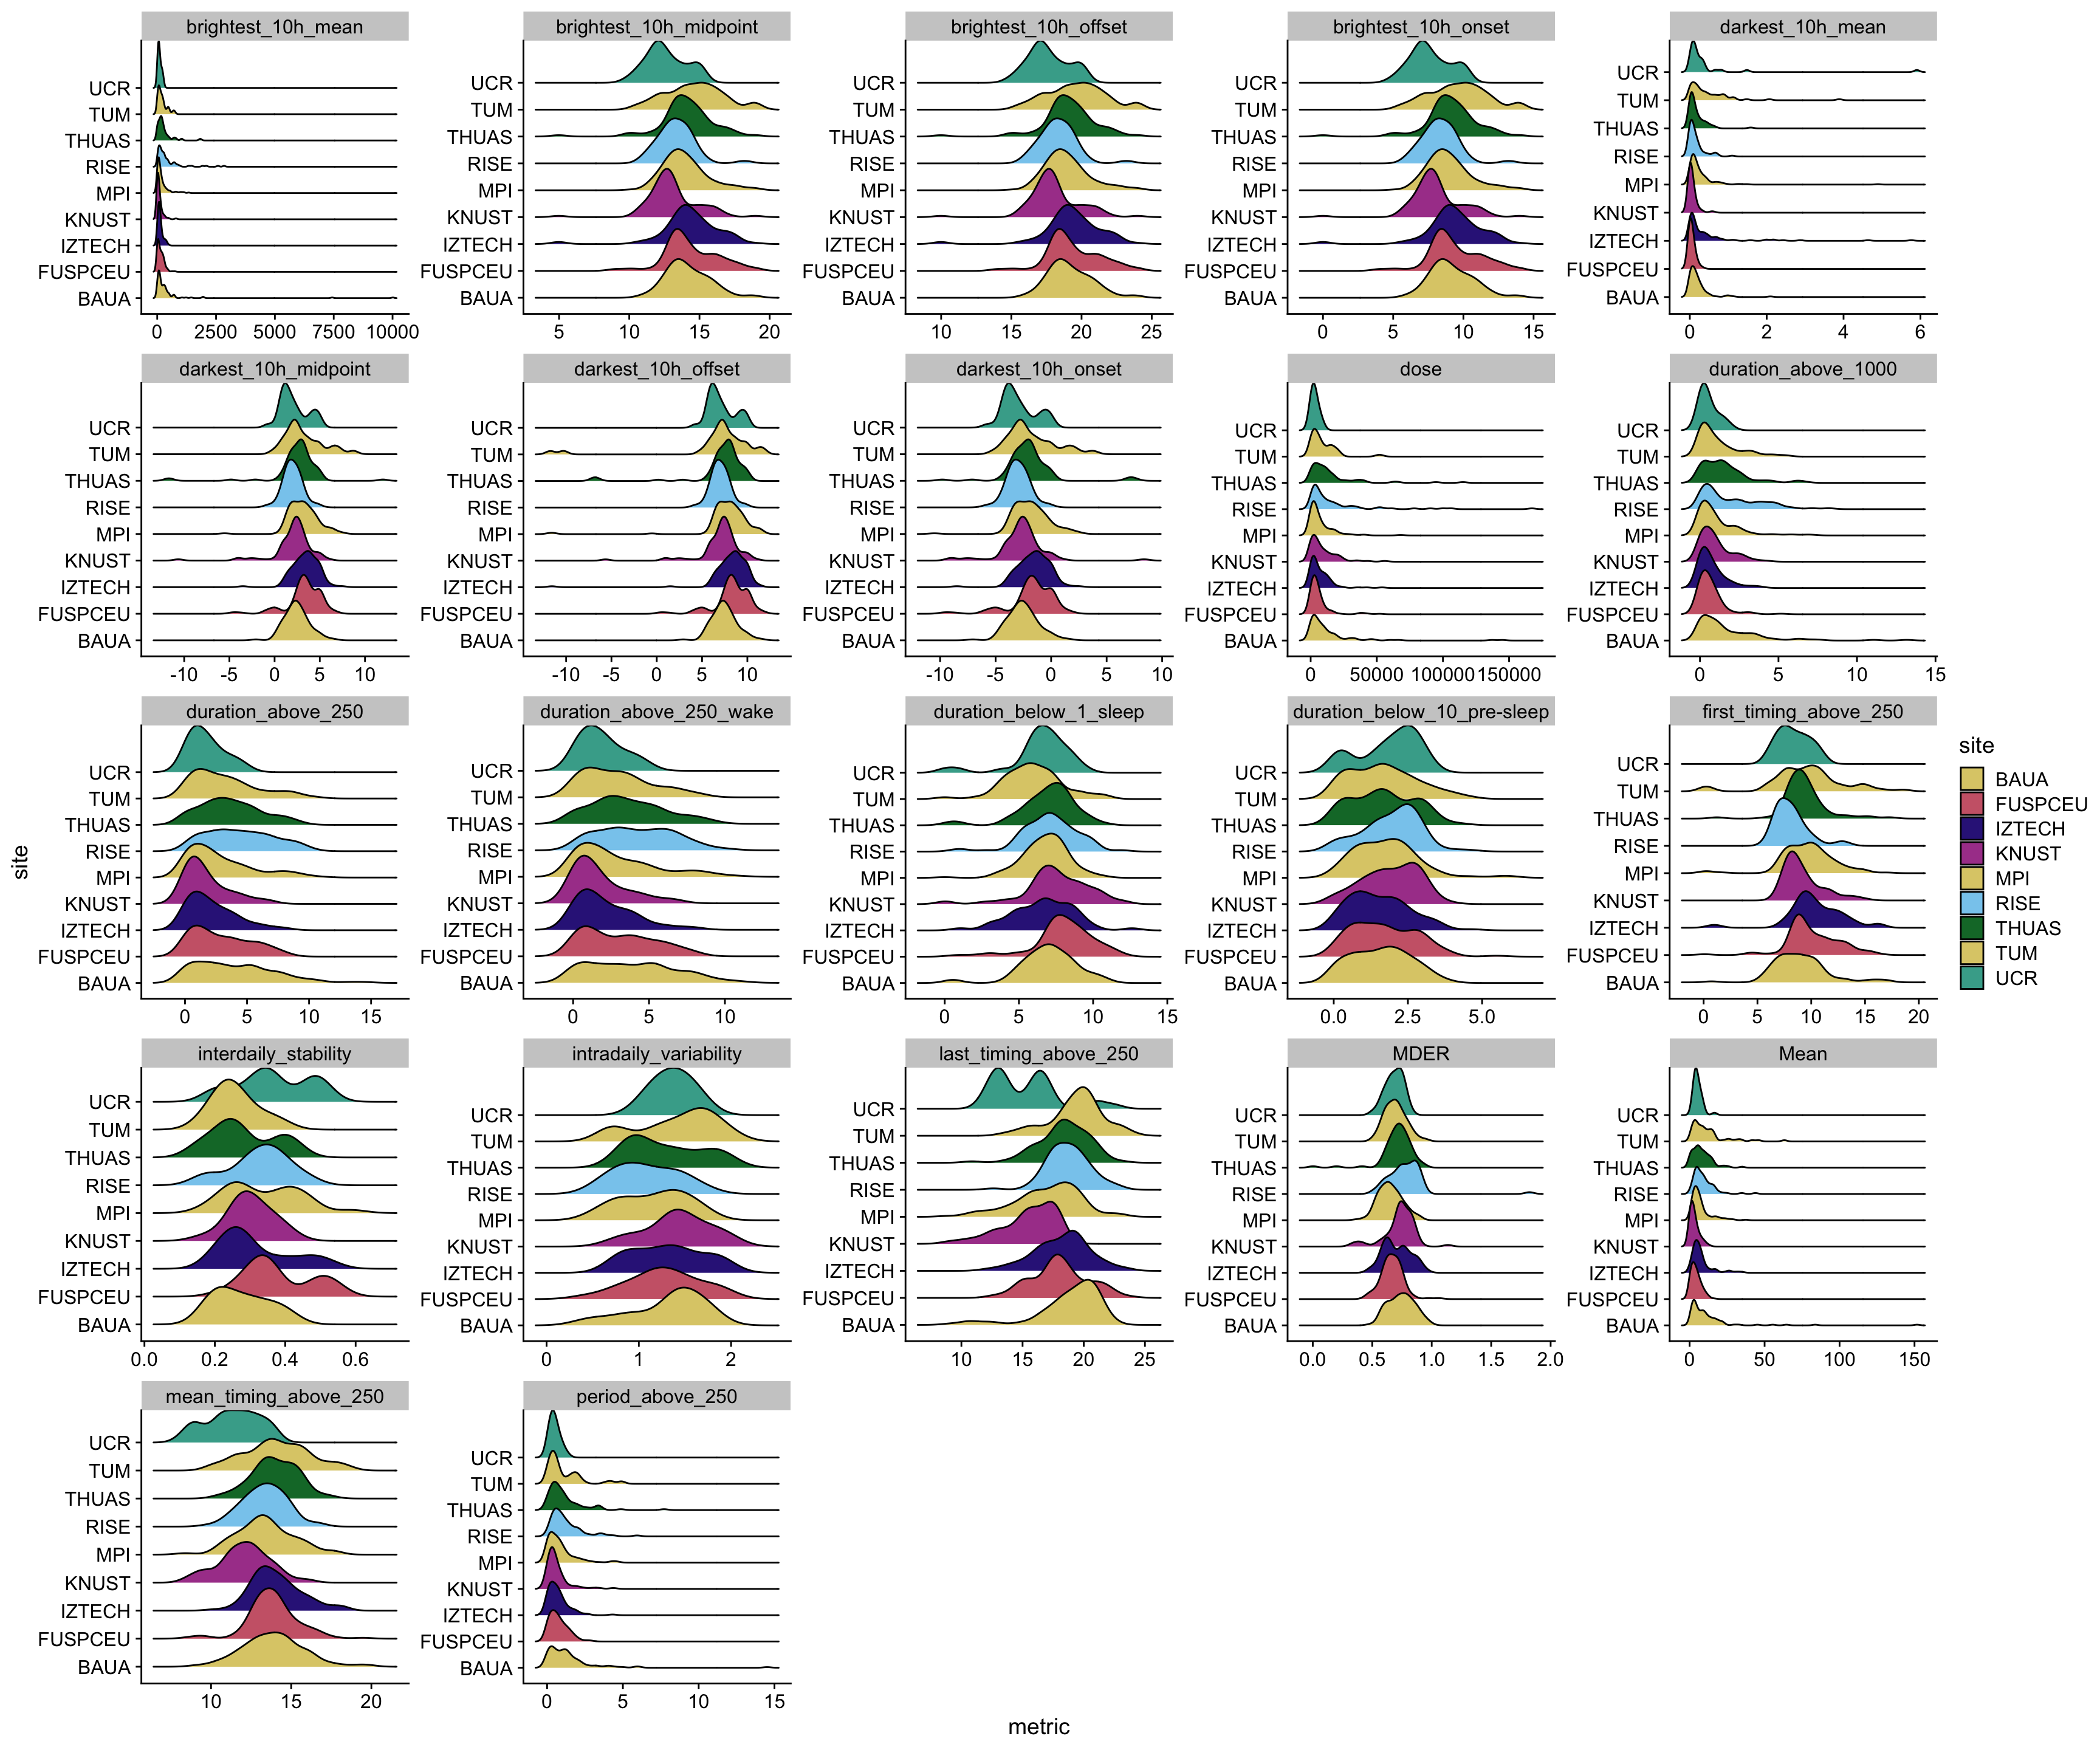

Picking joint bandwidth of 52.4

Picking joint bandwidth of 0.552
Picking joint bandwidth of 0.552
Picking joint bandwidth of 0.552

Picking joint bandwidth of 0.0695

Picking joint bandwidth of 0.503

Picking joint bandwidth of 0.49

...

Picking joint bandwidth of 0.0374

Picking joint bandwidth of 1.74

Picking joint bandwidth of 0.578

Picking joint bandwidth of 0.253

(`stat_density_ridges()`).

In [ ]:
metrics_glasses |> 
  unnest(data) |> 
  ggplot(aes(x=metric)) +
  geom_density_ridges(aes(y=site, fill = site))+
  facet_wrap(~ name, scales = "free") +
  scale_fill_manual(values = melidos_colors) +
  theme_cowplot()


Picking joint bandwidth of 50.7

Picking joint bandwidth of 0.572
Picking joint bandwidth of 0.572
Picking joint bandwidth of 0.572

Picking joint bandwidth of 0.051

Picking joint bandwidth of 0.494

Picking joint bandwidth of 0.519

...

Picking joint bandwidth of 0.0408

Picking joint bandwidth of 1.61

Picking joint bandwidth of 0.551

Picking joint bandwidth of 0.23

(`stat_density_ridges()`).

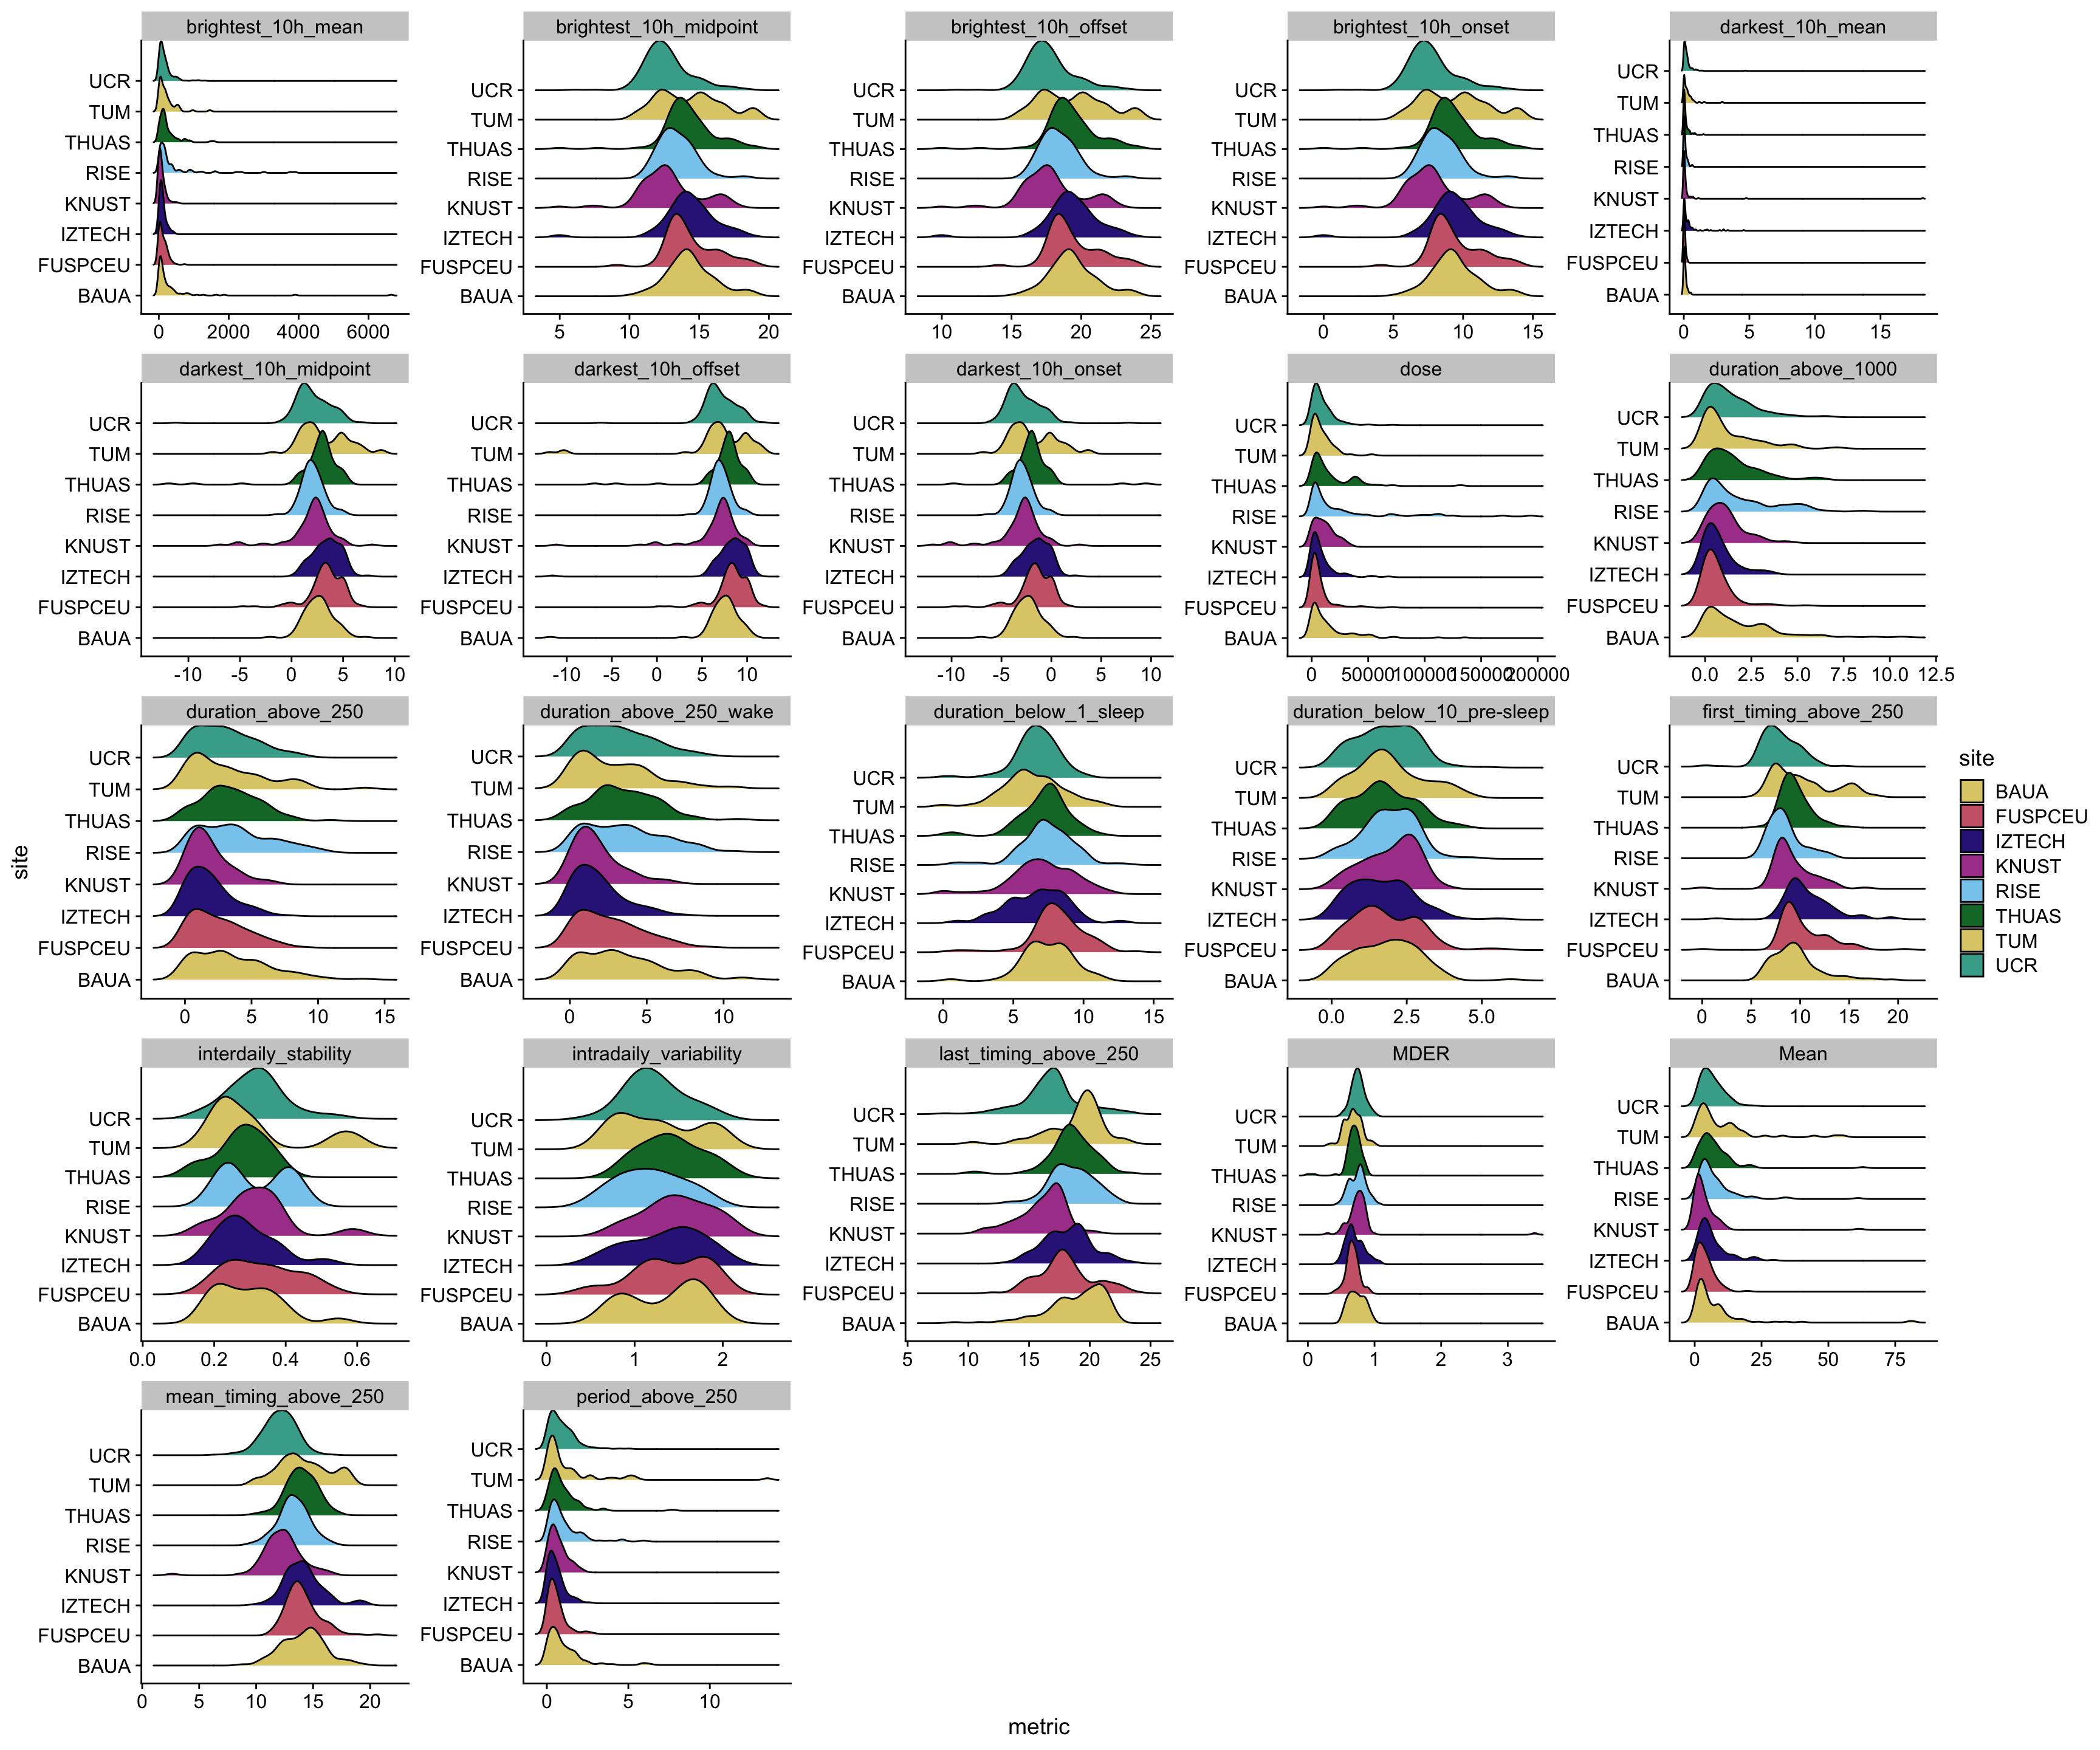

Picking joint bandwidth of 50.7

Picking joint bandwidth of 0.572
Picking joint bandwidth of 0.572
Picking joint bandwidth of 0.572

Picking joint bandwidth of 0.051

Picking joint bandwidth of 0.494

Picking joint bandwidth of 0.519

...

Picking joint bandwidth of 0.0408

Picking joint bandwidth of 1.61

Picking joint bandwidth of 0.551

Picking joint bandwidth of 0.23

(`stat_density_ridges()`).

In [ ]:
metrics_chest |> 
  unnest(data) |> 
  ggplot(aes(x=metric)) +
  geom_density_ridges(aes(y=site, fill = site))+
  facet_wrap(~ name, scales = "free") +
  scale_fill_manual(values = melidos_colors) +
  theme_cowplot()


### Export data

In [ ]:
save(metrics_glasses, file = "data/metrics_glasses.RData")
save(metrics_chest, file = "data/metrics_chest.RData")


```` markdown
---
title: "Personal light exposure: Metric preparation"
subtitle: "Individual, behavioural, and environmental determinants of personal light exposure in daily life: a multi-country wearable and experience-sampling study"
format: 
  html:
    code-tools: true
    code-link: true
---

## Preface

This script works off [the data preprocessing](data_preparation.qmd), to produce one dataframe containing all metrics in numeric form, ready for analysis.

### How metrics must be interpreted

- Timing and duration-based metrics are converted to decimal-hours. 
- In the case of timing they mean decimal-hours from midnight. 
- The `darkest_10h` are centered on midnight, i.e., values before midnight are negative.
- `mean` value metrics used a geometric mean (with `log_zero_inflated()`).

For a single, unnested dataframe of metrics execute:

```
metrics_glasses |> unnest(data)
```

## Setup

quarto-executable-code-5450563D

```r
#| message: false
#| warning: false
#| filename: Setup
library(tidyverse)
library(melidosData)
library(LightLogR)
library(mgcv)
library(readxl)
library(lme4)
library(performance)
library(cowplot)
library(ggridges)
library(downlit)
library(xml2)
```


quarto-executable-code-5450563D

```r
#| message: false
#| filename: Load data
load("data/metrics_separate_glasses.RData")
load("data/metrics_separate_chest.RData")
load("data/preprocessed_glasses_2.RData")
load("data/preprocessed_chest_2.RData")
demographics <- load_data("demographics") |> flatten_data()
```

## Preparation

### Context

quarto-executable-code-5450563D

```r
#| filename: Prepare photoperiods
photoperiod_daily <- 
light_glasses_processed2 |> 
  group_by(site, Id, Date) |> 
  summarize(photoperiod = mean(photoperiod, na.rm = TRUE) |> as.numeric(),
            .groups = "drop_last")

photoperiod_participant <- 
light_glasses_processed2 |> 
  group_by(site, Id) |> 
  summarize(photoperiod = mean(photoperiod, na.rm = TRUE) |> as.numeric(),
            .groups = "drop_last")

photoperiod_daily_chest <- 
light_chest_processed2 |> 
  group_by(site, Id, Date) |> 
  summarize(photoperiod = mean(photoperiod, na.rm = TRUE) |> as.numeric(),
            .groups = "drop_last")

photoperiod_participant_chest <- 
light_chest_processed2 |> 
  group_by(site, Id) |> 
  summarize(photoperiod = mean(photoperiod, na.rm = TRUE) |> as.numeric(),
            .groups = "drop_last")
```

quarto-executable-code-5450563D

```r
#| filename: Prepare contextual info
demographics <- 
  demographics |> 
  select(site, Id, age, sex, gender, employment_status)

context <- 
  tibble(site = names(melidos_cities),
         country = unname(melidos_countries),
         tz = unname(melidos_tzs),
         city = unname(melidos_cities),
         ) |> 
  left_join(
    melidos_coordinates |> map(enframe) |> list_rbind(names_to = "site") |> pivot_wider() |> rename(lat = `1`, lon = `2`),
    by = "site"
  )

demographics <- 
  demographics |> 
  left_join(context, by = join_by("site"))

```

### Metrics

In this section, we will combine all the metrics into one data-frame

quarto-executable-code-5450563D

```r
#| filename: Prepare participant metrics
metrics_glasses <- 
metric_glasses_participant |> 
  left_join(demographics, by = c("site", "Id")) |> 
  left_join(photoperiod_participant, by = c("site", "Id")) |> 
  pivot_longer(c(interdaily_stability, intradaily_variability), names_to = "name", values_to = "metric") |> 
  ungroup() |> 
  nest(.by = name) |> 
  mutate(type = "participant")

metrics_chest <- 
metric_chest_participant |> 
  left_join(demographics, by = c("site", "Id")) |> 
  left_join(photoperiod_participant_chest, by = c("site", "Id")) |> 
  pivot_longer(c(interdaily_stability, intradaily_variability), names_to = "name", values_to = "metric") |> 
  ungroup() |> 
  nest(.by = name) |> 
  mutate(type = "participant")
```

quarto-executable-code-5450563D

```r
#| filename: Prepare participant-day metrics
metrics_glasses <-
  rbind(
    metrics_glasses,
    metric_glasses_participantday |>
      #converting datetimes to times
      Datetime2Time() |>
      mutate(
        #converting times and durations to decimal hours
        across(c(where(hms::is_hms), where(is.duration)), 
               \(x) as.numeric(x) / 60 / 60),
        #centering nighttime variables on midnight
        across(
          c(darkest_10h_offset, darkest_10h_onset, darkest_10h_midpoint),
          \(x) ifelse(x > 12, x - 24, x)
        )
      ) |>
      left_join(demographics, by = c("site", "Id")) |> 
      left_join(photoperiod_daily, by = c("site", "Id", "Date")) |> 
      pivot_longer(c(Mean:duration_above_250_wake), names_to = "name", values_to = "metric") |>
      ungroup() |>
      nest(.by = name) |> 
      mutate(type = "participant-day")
  )

metrics_chest <-
  rbind(
    metrics_chest,
    metric_chest_participantday |>
      #converting datetimes to times
      Datetime2Time() |>
      mutate(
        #converting times and durations to decimal hours
        across(c(where(hms::is_hms), where(is.duration)), 
               \(x) as.numeric(x) / 60 / 60),
        #centering nighttime variables on midnight
        across(
          c(darkest_10h_offset, darkest_10h_onset, darkest_10h_midpoint),
          \(x) ifelse(x > 12, x - 24, x)
        )
      ) |>
      left_join(demographics, by = c("site", "Id")) |> 
      left_join(photoperiod_daily_chest, by = c("site", "Id", "Date")) |> 
      pivot_longer(c(Mean:duration_above_250_wake), names_to = "name", values_to = "metric") |>
      ungroup() |>
      nest(.by = name) |> 
      mutate(type = "participant-day")
  )
```

quarto-executable-code-5450563D

```r
types <- read_excel("data/metric_types.xlsx")
```


quarto-executable-code-5450563D

```r
metrics_glasses <-
  metrics_glasses |> 
  unnest(data) |> 
  mutate(across(c(site, Id, country, city, Date), factor)) |> 
  nest(data = -c(name, type)) |> 
  left_join(types, by = "name")

metrics_chest <-
  metrics_chest |> 
  unnest(data) |> 
  mutate(across(c(site, Id, country, city, Date), factor)) |> 
  nest(data = -c(name, type)) |> 
  left_join(types, by = "name")
```


### Distributional characteristics

quarto-executable-code-5450563D

```r
#| fig-width: 18
#| fig-height: 15
#| message: false
metrics_glasses |> 
  unnest(data) |> 
  ggplot(aes(x=metric)) +
  geom_density_ridges(aes(y=site, fill = site))+
  facet_wrap(~ name, scales = "free") +
  scale_fill_manual(values = melidos_colors) +
  theme_cowplot()

ggsave("figures/exploration/metric_distribution_glasses.pdf", width = 18, height = 15)
```

quarto-executable-code-5450563D

```r
#| fig-width: 18
#| fig-height: 15
#| message: false
metrics_chest |> 
  unnest(data) |> 
  ggplot(aes(x=metric)) +
  geom_density_ridges(aes(y=site, fill = site))+
  facet_wrap(~ name, scales = "free") +
  scale_fill_manual(values = melidos_colors) +
  theme_cowplot()

ggsave("figures/exploration/metric_distribution_chest.pdf", width = 18, height = 15)
```

### Export data

quarto-executable-code-5450563D

```r
save(metrics_glasses, file = "data/metrics_glasses.RData")
save(metrics_chest, file = "data/metrics_chest.RData")
```
````